In [1]:
# Criar o ambiente
#conda create -n tcc_gustavo python=3.11

# Ativar o ambiente
#conda activate tcc_gustavo

# Instalar as bibliotecas essenciais citadas no seu TCC
# conda install pandas numpy matplotlib seaborn scikit-learn jupyter

#pip install xgboost shap
#pip install reverse_geocoder
#pip install geopandas shapely
#pip install geobr

#import pandas as pd

In [2]:
#Ler as bases
#import pandas as pd
#eletricista_db = pd.read_csv(r'C:\Users\Avell\Desktop\2025.2\tcc\BASE_EXPERIMENTAL\eletricista.csv')
#empreiteira_db = pd.read_csv(r'empreiteira.csv')
#equipe_habilidade_db = pd.read_csv(r'equipe_habilidade_relacionamento.csv')
#equipe_veiculo_db = pd.read_csv(r'equipe_veiculo_relacionamento.csv')
#equipe_db = pd.read_csv(r'equipe.csv')
#process_db = pd.read_csv(r'C:\Users\Avell\Desktop\2025.2\tcc\BASE_EXPERIMENTAL\processo.csv')
#servico_executado = pd.read_csv(r'servico_executado.csv')
#turno_db = pd.read_csv(r'C:\Users\Avell\Desktop\2025.2\tcc\BASE_EXPERIMENTAL\turno.csv')
#veiculo_db = pd.read_csv(r'C:\Users\Avell\Desktop\2025.2\tcc\BASE_EXPERIMENTAL\veiculo.csv')
#equipe_eletricista_relacionamento = pd.read_csv(r'C:\Users\Avell\Desktop\2025.2\tcc\BASE_EXPERIMENTAL\equipe_eletricista_relacionamento.csv')


Carregando bases...
Dataset                             | % Não-nulos 
--------------------------------------------------
servico_executado                   |       37.2%
equipe                              |       90.1%
eletricista                         |       28.2%
veiculo                             |       28.6%
turno                               |       82.1%
empreiteira                         |       99.9%
processo                            |      100.0%
equipe_habilidade_relacionamento    |      100.0%
equipe_veiculo_relacionamento       |      100.0%
equipe_eletricista_relacionamento   |      100.0%
Iniciando integração relacional...
Executando saneamento estatístico...
Enriquecendo dados (Tempo, Geo e Clima)...
Loading formatted geocoded file...
Dataset final com 1,862,155 registros salvos.


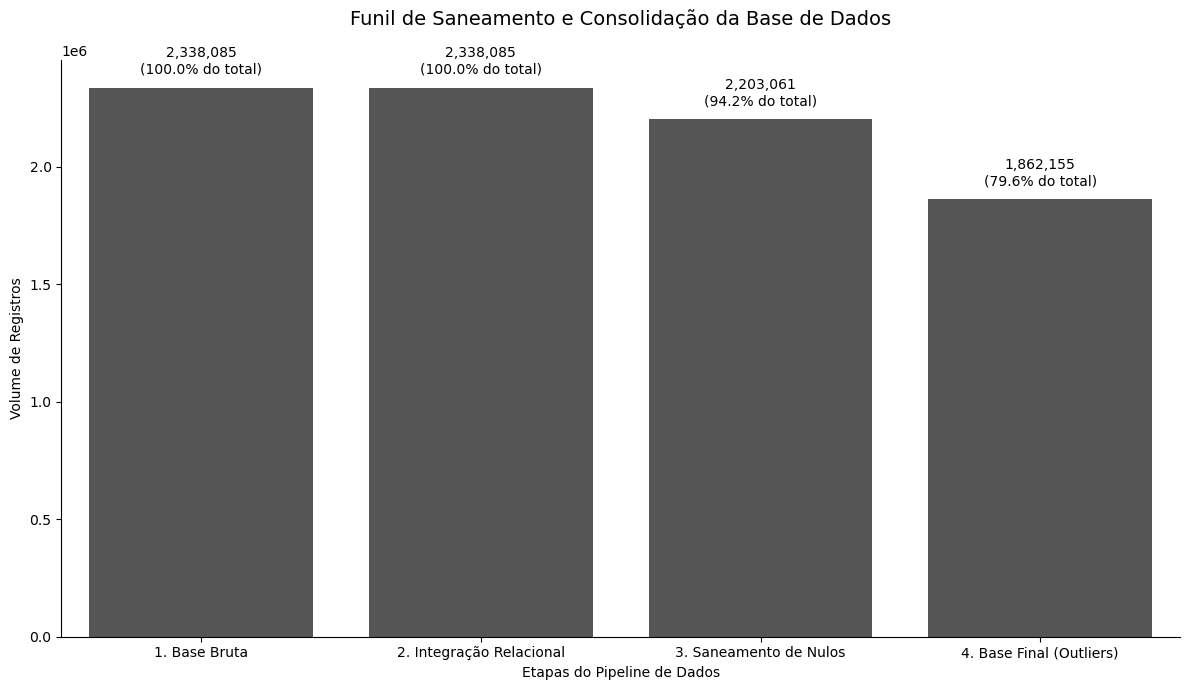

Index(['id_servico', 'processo', 'tipo_de_servico', 'subtipo_de_servico',
       'descricao_do_servico', 'abrangencia_impacto',
       'servicos_efetivamente_executados', 'materiais_efetivamente_utilizados',
       'materiais_inicialmente_previstos', 'acesso_ao_local_do_trabalho',
       'tensao', 'quantidade_de_fases', 'grupo_tarifario',
       'ramal_do_mesmo_lado_da_rua', 'local_do_corte', 'data_primeira_ligacao',
       'data_ultima_ligacao', 'atende_a_norma_vigente', 'tipo_de_imovel',
       'base', 'municipio', 'bairro', 'workzone', 'latitude', 'longitude',
       'area_de_risco', 'urbano_rural', 'id_equipe_data', 'equipe_da_base',
       'informacao_eletricista_clima', 'previsao_do_clima', 'datahora_inicio',
       'datahora_fim', 'temperatura_previsao', 'momento_no_turno',
       'duracao_prevista_tempo_servico', 'duracao_real_tempo_servico',
       'duracao_deslocamento', 'improdutivo', 'id_equipe', 'nome_equipe',
       'resource_id', 'empreiteira_id', 'id', 'nome', 'nome_com

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import reverse_geocoder as rg
import requests
import time
import holidays
from datetime import datetime
import os

# ==============================================================================
# 1. CONFIGURAÇÕES E CARREGAMENTO
# ==============================================================================
base_path = r'C:\Users\Avell\Desktop\2025.2\tcc\BASE_EXPERIMENTAL\\'

def otimizar_memoria(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type == object:
            if df[col].nunique() / len(df) < 0.05:
                df[col] = df[col].astype('category')
        elif str(col_type).startswith('int'):
            df[col] = pd.to_numeric(df[col], downcast='integer')
        elif str(col_type).startswith('float'):
            df[col] = pd.to_numeric(df[col], downcast='float')
    return df

print("Carregando bases...")
fato = pd.read_csv(base_path + 'servico_executado.csv')
equipe = pd.read_csv(base_path + 'equipe.csv')
processo_dim = pd.read_csv(base_path + 'processo.csv')
turno = pd.read_csv(base_path + 'turno.csv')
empreiteira = pd.read_csv(base_path + 'empreiteira.csv')
composicao = pd.read_csv(base_path + 'equipe_eletricista_relacionamento.csv')



# Lista de arquivos conforme seu script
caminho_base = r'C:\Users\Avell\Desktop\2025.2\tcc\BASE_EXPERIMENTAL'
arquivos = {
    'servico_executado': 'servico_executado.csv',
    'equipe': 'equipe.csv',
    'eletricista': 'eletricista.csv',
    'veiculo': 'veiculo.csv',
    'turno': 'turno.csv',
    'empreiteira': 'empreiteira.csv',
    'processo': 'processo.csv',
    'equipe_habilidade_relacionamento': 'equipe_habilidade_relacionamento.csv',
    'equipe_veiculo_relacionamento': 'equipe_veiculo_relacionamento.csv',
    'equipe_eletricista_relacionamento': 'equipe_eletricista_relacionamento.csv'
}

print(f"{'Dataset':<35} | {'% Não-nulos':<12}")
print("-" * 50)

for nome, arquivo in arquivos.items():
    try:
        # Tenta ler o arquivo (ajuste o separador se necessário, ex: sep=';')
        df_temp = pd.read_csv(os.path.join(caminho_base, arquivo), low_memory=False)
        
        # Cálculo da porcentagem total de células não nulas
        completude = (1 - df_temp.isnull().mean().mean()) * 100
        
        print(f"{nome:<35} | {completude:>10.1f}%")
    except Exception as e:
        print(f"{nome:<35} | Erro ao ler arquivo")

# ==============================================================================
# 2. INTEGRAÇÃO RELACIONAL (MODELO SNOWFLAKE)
# ==============================================================================
print("Iniciando integração relacional...")

# 2.1 Processamento do Fator Humano
equipe_dimensao = composicao.groupby('equipe_data_id').agg({
    'eletricista_id': 'nunique'
}).rename(columns={'eletricista_id': 'qtd_eletricistas_real'}).reset_index()

# 2.2 Normalização de Tipos
fato['processo'] = fato['processo'].fillna(-1).astype(int).astype(str)
processo_dim['id'] = processo_dim['id'].astype(int).astype(str)

# 2.3 Execução dos Joins (BLOCO ÚNICO E ORGANIZADO)
# Fato -> Turno -> Equipe -> Empreiteira -> Processo -> Composição
df_master = fato.merge(turno[['id_equipe_data', 'id_equipe']], on='id_equipe_data', how='left')
df_master = df_master.merge(equipe, left_on='id_equipe', right_on='id', how='left')
df_master = df_master.drop(columns=['id'])
df_master = df_master.merge(empreiteira, left_on='empreiteira_id', right_on='id', how='left', suffixes=('', '_emp'))
df_master = df_master.merge(processo_dim, left_on='processo', right_on='id', how='left', suffixes=('', '_proc'))
df_master = df_master.merge(equipe_dimensao, left_on='id_equipe_data', right_on='equipe_data_id', how='left')

# CAPTURA 1: Volume total após a integração relacional
total_integrado = len(df_master) 

# ==============================================================================
# 3. SANEAMENTO E FILTRAGEM
# ==============================================================================
print("Executando saneamento estatístico...")

# Padronização e Limpeza de Nulos
df_master['datahora_inicio'] = pd.to_datetime(df_master['datahora_inicio'], errors='coerce')
df_master['datahora_fim'] = pd.to_datetime(df_master['datahora_fim'], errors='coerce')
df_master = df_master.dropna(subset=['datahora_inicio', 'datahora_fim', 'latitude', 'longitude'])

# CAPTURA 2: Volume após a remoção de registros nulos
total_sem_nulos = len(df_master) 

# Filtro de Outliers (2-Sigma)
LIMITE_SUPERIOR = 125
mask_valido = (df_master['duracao_real_tempo_servico'] > 0) & \
              (df_master['duracao_real_tempo_servico'] <= LIMITE_SUPERIOR)

df_final = df_master[mask_valido].copy()

# ==============================================================================
# 4. ENRIQUECIMENTO CONTEXTUAL
# ==============================================================================
print("Enriquecendo dados (Tempo, Geo e Clima)...")

# 4.1 Feriados e Turnos
br_holidays = holidays.Brazil()
df_final['dia_semana'] = df_final['datahora_inicio'].dt.dayofweek
df_final['is_fds'] = (df_final['dia_semana'] >= 5).astype(int)
df_final['is_feriado'] = df_final['datahora_inicio'].apply(lambda x: 1 if x in br_holidays else 0)
df_final['hora_inicio'] = df_final['datahora_inicio'].dt.hour
df_final['turno_dia'] = pd.cut(df_final['hora_inicio'], bins=[-1, 5, 12, 18, 24], 
                               labels=['Madrugada', 'Manhã', 'Tarde', 'Noite'])

# 4.2 Geocodificação Reversa
df_geo = df_final[['latitude', 'longitude']].drop_duplicates().dropna()
coords = list(zip(df_geo['latitude'], df_geo['longitude']))
resultados_geo = rg.search(coords)
df_geo['cidade_geo'] = [res['name'] for res in resultados_geo]
df_geo['estado_geo'] = [res['admin1'] for res in resultados_geo]
df_final = df_final.merge(df_geo, on=['latitude', 'longitude'], how='left')

# 4.3 Clima (Open-Meteo)
polos = df_final['cidade_geo'].value_counts().nlargest(10).index.tolist()
lista_clima = []

for cidade in polos:
    loc = df_final[df_final['cidade_geo'] == cidade].iloc[0]
    start_d = df_final['datahora_inicio'].min().strftime('%Y-%m-%d')
    end_d = df_final['datahora_inicio'].max().strftime('%Y-%m-%d')
    
    params = "precipitation_sum,temperature_2m_mean,wind_speed_10m_max"
    url = f"https://archive-api.open-meteo.com/v1/archive?latitude={loc['latitude']}&longitude={loc['longitude']}&start_date={start_d}&end_date={end_d}&daily={params}&timezone=America%2FSao_Paulo"
    
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            js = r.json()
            df_c = pd.DataFrame({
                'data_clima': pd.to_datetime(js['daily']['time']).date,
                'precipitacao_mm': js['daily']['precipitation_sum'],
                'temp_media': js['daily']['temperature_2m_mean'],
                'vento_max_kmh': js['daily']['wind_speed_10m_max'],
                'cidade_geo': cidade
            })
            lista_clima.append(df_c)
        time.sleep(0.5)
    except:
        continue

if lista_clima:
    df_clima_total = pd.concat(lista_clima)
    df_final['data_join'] = df_final['datahora_inicio'].dt.date
    
    # CORREÇÃO DO MERGE: Usando left_on e right_on para bater as datas
    df_final = df_final.merge(df_clima_total, 
                              left_on=['cidade_geo', 'data_join'], 
                              right_on=['cidade_geo', 'data_clima'], 
                              how='left')
    
    df_final['precipitacao_mm'] = df_final['precipitacao_mm'].fillna(0)
    df_final['temp_media'] = df_final['temp_media'].fillna(df_final['temp_media'].median())
    df_final['vento_max_kmh'] = df_final['vento_max_kmh'].fillna(df_final['vento_max_kmh'].median())
    df_final['is_chuva'] = (df_final['precipitacao_mm'] > 0.5).astype(int)
    df_final['is_ventania'] = (df_final['vento_max_kmh'] > 30).astype(int)
    
    df_final = df_final.drop(columns=['data_join', 'data_clima'])

total_final = len(df_final)

# Exportação e Gráfico de Funil
df_final.to_csv('base_enriquecida_tcc_v2.csv', index=False)
print(f"Dataset final com {df_final.shape[0]:,} registros salvos.")

# --- NOVO GRÁFICO DE FUNIL DE SANEAMENTO (ACADÊMICO) ---

total_original = len(fato) # fato ou servico_executado conforme seu carregamento

counts = {
    '1. Base Bruta': total_original,
    '2. Integração Relacional': total_integrado,
    '3. Saneamento de Nulos': total_sem_nulos,
    '4. Base Final (Outliers)': total_final
}

plt.figure(figsize=(12, 7))
ax = sns.barplot(x=list(counts.keys()), y=list(counts.values()), color='#555555')

for p in ax.patches:
    valor = int(p.get_height())
    percentual_total = (valor / total_original) * 100
    ax.annotate(f'{valor:,}\n({percentual_total:.1f}% do total)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, xytext=(0, 8), textcoords='offset points')

plt.title('Funil de Saneamento e Consolidação da Base de Dados', fontsize=14, pad=25)
plt.ylabel('Volume de Registros')
plt.xlabel('Etapas do Pipeline de Dados')
sns.despine()
plt.tight_layout()
plt.show()

print(df_final.columns)

In [5]:
print(df_final['id_equipe_data'][:10])

0    202505180004605
1    202505180004605
2    202506010011774
3    202506210011789
4    202505180004556
5    202507270010160
6    202505250011361
7    202506150004557
8    202506130010213
9    202506130010213
Name: id_equipe_data, dtype: int64
